In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('matlab.mplstyle')

# text = open(r'S:\1.FILE\xxx.CSV', "r")
# text = ''.join([i for i in text]).replace(",", ".")
# text = ''.join([i for i in text]).replace(";", ",")

# x = open('edited.csv',"w")
# x.writelines(text)
# x.close()

In [33]:
data = np.genfromtxt(r"S:\1.FILE\pok\wera.CSV", delimiter=',', skip_header=1)
X = data[: , 0]/6e4
tep = data[: , 1]
ot = data[: , 2]

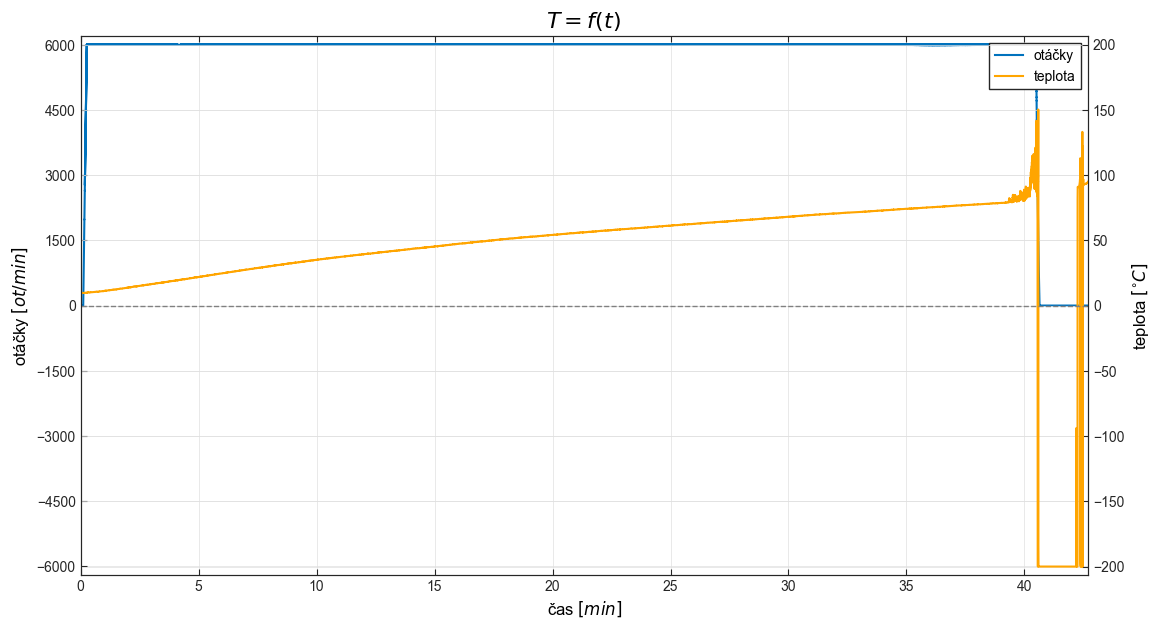

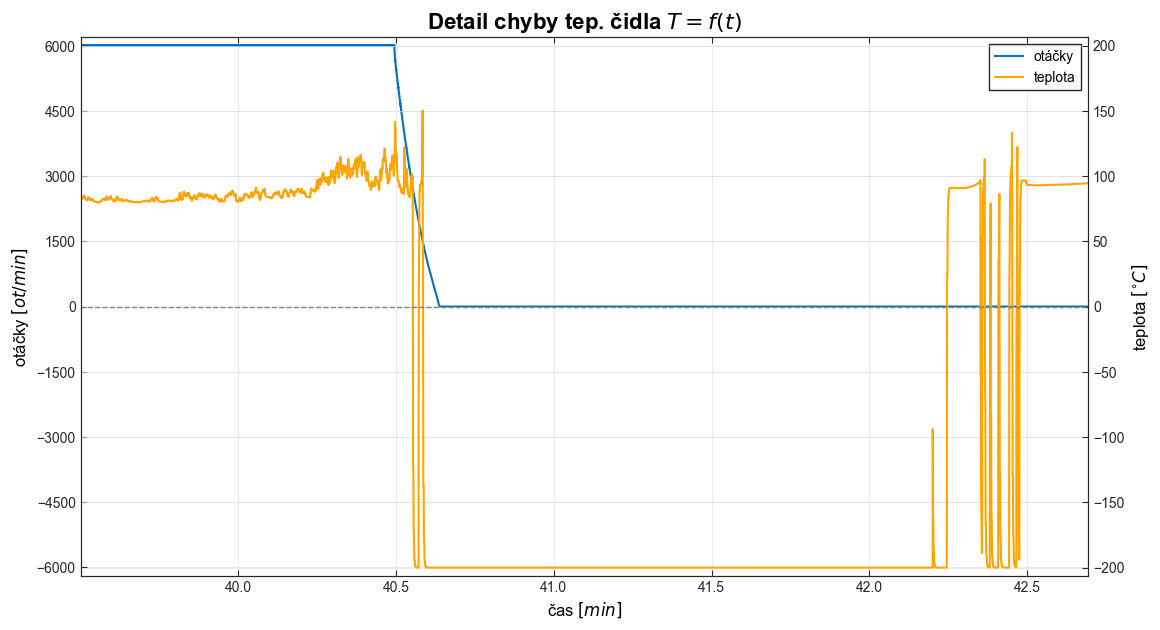

In [34]:
d_tep = np.diff(tep)
prah = 0.5
indexy_poklesu = np.where(abs(d_tep) > prah)[0]
if np.size(indexy_poklesu) == 0:
    indexy_poklesu = np.append(indexy_poklesu, [0])
    print("Teplotní čidlo je v pořádku")

#print(np.mean(abs(d_tep)),np.min(abs(d_tep)),np.max(abs(d_tep)))

fig, host = plt.subplots(figsize=(13,7))
ax2 = host.twinx()  
host.set_xlim(0, X[-1])
host.set_ylim(-6200, 6200)
ax2.set_ylim(-206.5, 206.5)

p1 = host.plot(X, ot, label="otáčky")
p2 = ax2.plot(X, tep, label="teplota", color='orange')

plt.hlines(0,0, X[-1],color='gray',linestyle='--',linewidth=1)

plt.title(r"$T=f(t)$ ", fontsize=16, color='k')
host.legend(handles=p1+p2, loc='upper right')
# host.set_yticks(np.arange(-120, 140, step=40))
host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(p2[0].get_color())

host.set_yticks([-6000,-4500,-3000,-1500,0,1500,3000,4500,6000]) 

host.set_xlabel("čas $[min]$", fontsize=12, color = 'k')
host.set_ylabel("otáčky $[ot/min]$", fontsize=12, color = 'k')
ax2.set_ylabel(r"teplota $[^{\circ}C]$", fontsize=12, color = 'k')

plt.show()

if indexy_poklesu[0] != 0:
    fig, host = plt.subplots(figsize=(13,7))
    ax2 = host.twinx()  
    host.set_xlim(X[indexy_poklesu[0]], X[-1])
    host.set_ylim(-6200, 6200)
    ax2.set_ylim(-206.5, 206.5)

    p1 = host.plot(X, ot, label="otáčky")
    p2 = ax2.plot(X, tep, label="teplota", color='orange')

    plt.hlines(0,0, X[-1],color='gray',linestyle='--',linewidth=1)

    plt.title(r"Detail chyby tep. čidla $T=f(t)$", fontsize=16, color='k')
    host.legend(handles=p1+p2, loc='upper right')
    # host.set_yticks(np.arange(-120, 140, step=40))
    host.yaxis.label.set_color(p1[0].get_color())
    ax2.yaxis.label.set_color(p2[0].get_color())

    host.set_yticks([-6000,-4500,-3000,-1500,0,1500,3000,4500,6000]) 

    host.set_xlabel("čas $[min]$", fontsize=12, color = 'k')
    host.set_ylabel("otáčky $[ot/min]$", fontsize=12, color = 'k')
    ax2.set_ylabel(r"teplota $[^{\circ}C]$", fontsize=12, color = 'k')

    plt.show()